In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [4]:
#Load the dataset
df=pd.read_csv("Downloads/ai_job_impact.csv")
df.head()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


# EDA

In [5]:
#Check is there any missing value
df.isnull().sum()

Employee_ID              0
Age                      0
Gender                   0
Education_Level          0
Industry                 0
Job_Role                 0
Years_Experience         0
AI_Adoption_Level        0
Automation_Risk          0
Upskilling_Required      0
Salary_Before_AI         0
Salary_After_AI          0
Job_Status               0
Work_Hours_Per_Week      0
Remote_Work              0
Job_Satisfaction         0
Productivity_Change_%    0
dtype: int64

In [6]:
#check the info about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            2000 non-null   object 
 1   Age                    2000 non-null   int64  
 2   Gender                 2000 non-null   object 
 3   Education_Level        2000 non-null   object 
 4   Industry               2000 non-null   object 
 5   Job_Role               2000 non-null   object 
 6   Years_Experience       2000 non-null   int64  
 7   AI_Adoption_Level      2000 non-null   object 
 8   Automation_Risk        2000 non-null   object 
 9   Upskilling_Required    2000 non-null   object 
 10  Salary_Before_AI       2000 non-null   int64  
 11  Salary_After_AI        2000 non-null   int64  
 12  Job_Status             2000 non-null   object 
 13  Work_Hours_Per_Week    2000 non-null   int64  
 14  Remote_Work            2000 non-null   object 
 15  Job_

In [7]:
#Check number of rows and columns
df.shape

(2000, 17)

In [8]:
#Check numeric columns statistic summary
df.describe()

,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,40.558000,16.663500,73942.072500,78428.642500,44.85100,6.020500,9.785820
std,10.786418,10.746675,26055.823793,29351.599013,5.71254,2.006263,17.187882
min,22.000000,0.000000,30036.000000,24447.000000,35.00000,3.000000,-19.990000
25%,32.000000,8.000000,51665.500000,54086.750000,40.00000,4.000000,-5.355000
50%,40.000000,16.000000,74620.000000,76820.500000,45.00000,6.000000,9.850000
75%,50.000000,26.000000,95418.250000,100730.250000,50.00000,8.000000,24.582500
max,59.000000,37.000000,119976.000000,161745.000000,54.00000,9.000000,39.990000


#### Q1:What is the distribution of Productivity_Change_%?

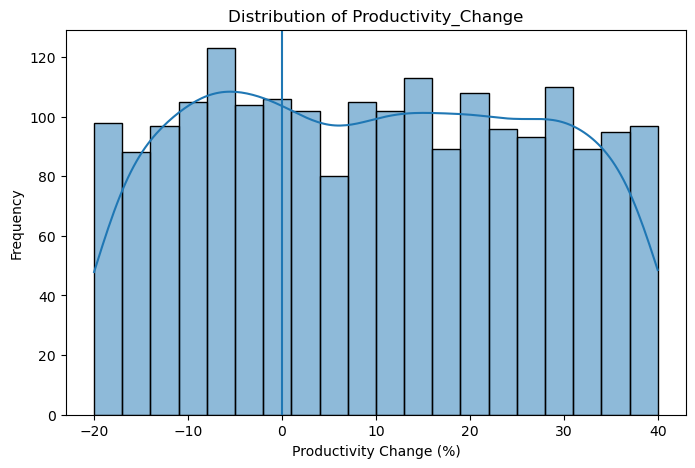

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(x='Productivity_Change_%',data=df ,bins=20,kde=True)
plt.title('Distribution of Productivity_Change')

#Add the vertical line in the middle point (0)
plt.axvline(0)

plt.xlabel("Productivity Change (%)")
plt.ylabel("Frequency")

plt.show()

 As we can see it is roughly symmetrical. 

#### Conclusion:
The histogram shows that productivity change is spread on both positive and negative sides,with most values
near ZERO.This mean AI has a mixed effect__it improve productivity for some Employess but also decrease some
Employess productivity.The overall change of AI on Productivity is very small, which means AI doesn't have a big impact 
on Productivity Change


"Most employees show small changes in productivity, while fewer employees experience large increases or decreases.”


#### Q2:What is the distribution of Job Satisfaction?
means most of the Employees are satisfied with the Job or not?

In [10]:
#Check what are the satifaction values in the data set
df['Job_Satisfaction'].unique()

array([5, 6, 3, 9, 8, 4, 7])

C:\Users\Samman\AppData\Local\Temp\ipykernel_3956\397015798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Job_Satisfaction", data=df , palette='bright')


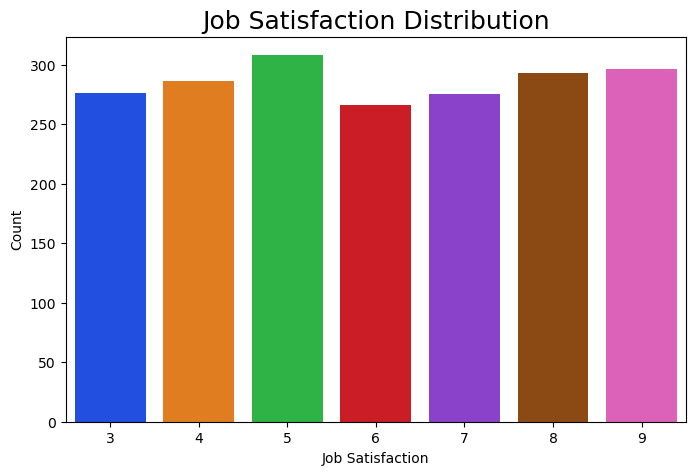

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="Job_Satisfaction", data=df , palette='bright')

plt.title("Job Satisfaction Distribution", fontsize=18)
plt.xlabel("Job Satisfaction")
plt.ylabel("Count")

plt.show()

#### Conclusion:

Employees show a mix of satisfaction levels, but overall most are moderately to highly satisfied with their jobs.

#### Q3:How are employees distributed across AI_Adoption_Level (Low, Medium, High)?

C:\Users\Samman\AppData\Local\Temp\ipykernel_3956\3807942313.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="AI_Adoption_Level", data=df, order=order, palette='crest')


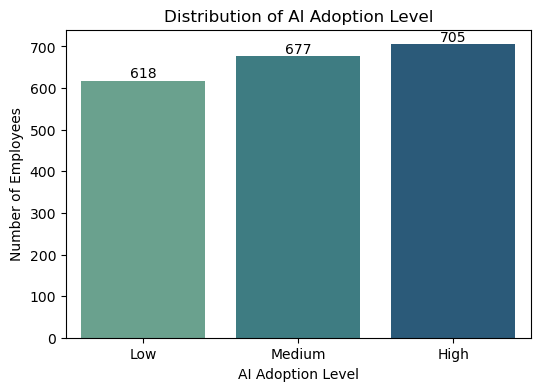

In [12]:
plt.figure(figsize=(6,4))

order = ["Low", "Medium", "High"]
ax = sns.countplot(x="AI_Adoption_Level", data=df, order=order, palette='crest')

# Add labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of AI Adoption Level")
plt.xlabel("AI Adoption Level")
plt.ylabel("Number of Employees")

plt.show()

#### Conclusion:

AI adoption is quite balanced across employees, with slightly more people using AI at a high level. 
This means AI is commonly used, but not all employees are using it at the same level.

#### Q4:Is there any null value in the dataset?

In [24]:
df.isnull().sum().sum()

np.int64(0)

#### Q5:Connectivity between AI-Adoption and Productivity Change

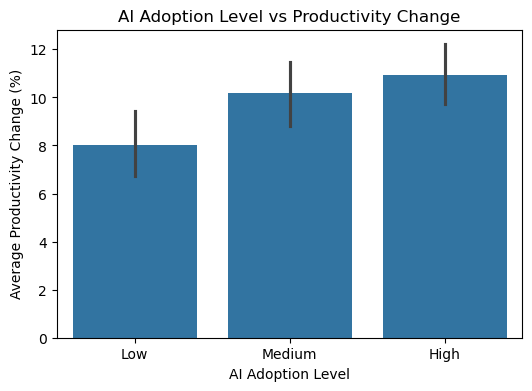

In [13]:
plt.figure(figsize=(6,4))

order = ["Low", "Medium", "High"]

sns.barplot(x="AI_Adoption_Level", y="Productivity_Change_%", data=df, order=order)

plt.title("AI Adoption Level vs Productivity Change")
plt.xlabel("AI Adoption Level")
plt.ylabel("Average Productivity Change (%)")

plt.show()

#### Conclusion:
* Employees who use more AI tend to have higher productivity
* There is a positive relationship between AI adoption and productivity

#### Q6:Which industries have the highest number of employees?

In [14]:
#We check what are the industries we have
df['Industry'].unique()

array(['Marketing', 'Manufacturing', 'IT', 'Education', 'Healthcare',
       'Finance', 'Retail'], dtype=object)

C:\Users\Samman\AppData\Local\Temp\ipykernel_3956\2739415596.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='Industry', data=df, palette='Accent_r')


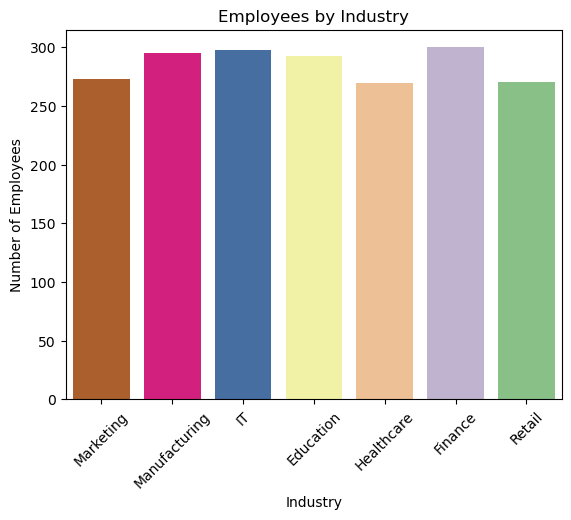

In [15]:
#Draw countplot
ax=sns.countplot(x='Industry', data=df, palette='Accent_r')

#Rotation of lables
plt.xticks(rotation=45)

#Lables
plt.title("Employees by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Employees")


plt.show()

#### Conclusion:

As we can see all industries have good number of Employees but Finance industry slightly has the highest num of Employees.

#### Q7:How many employees fall into each Automation_Risk category?

In [16]:
#What are the values we have in Automation_Risk
df['Automation_Risk'].unique()

array(['High', 'Low', 'Medium'], dtype=object)

C:\Users\Samman\AppData\Local\Temp\ipykernel_3956\1003677427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='Automation_Risk', data=df , palette='bright', order=order)


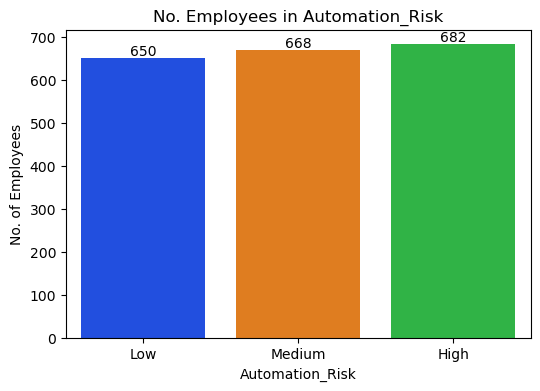

In [17]:
plt.figure(figsize=(6,4))

order=['Low','Medium','High']

ax=sns.countplot(x='Automation_Risk', data=df , palette='bright', order=order)

# Add labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('No. Employees in Automation_Risk')
plt.xlabel('Automation_Risk')
plt.ylabel('No. of Employees')

plt.show()

#### Conclusion:
* Many jobs are affected by automation, suggesting the need for employee upskilling
* Without upskilling, employees in higher-risk roles may face job uncertainty due to automation.

#### Q8:What is the average value of Productivity_Change_% by AI_Adoption_Level

In [18]:
#Productivity and AI_Apodtion_Level
df.groupby('AI_Adoption_Level')['Productivity_Change_%'].mean().sort_values()

AI_Adoption_Level
Low        8.031262
Medium    10.174579
High      10.950539
Name: Productivity_Change_%, dtype: float64

In [20]:
df.groupby("AI_Adoption_Level")["Job_Satisfaction"].mean().sort_values()

AI_Adoption_Level
Medium    5.986706
High      6.029787
Low       6.046926
Name: Job_Satisfaction, dtype: float64

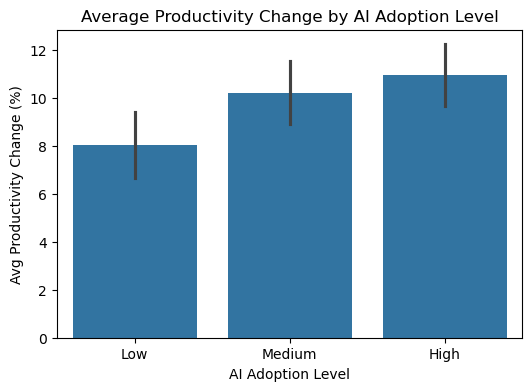

In [19]:
#Visualization
plt.figure(figsize=(6,4))

order = ["Low", "Medium", "High"]

sns.barplot(x="AI_Adoption_Level", y="Productivity_Change_%", data=df, order=order)

plt.title("Average Productivity Change by AI Adoption Level")
plt.xlabel("AI Adoption Level")
plt.ylabel("Avg Productivity Change (%)")

plt.show()

#### Q9:What is the average value of Job_Satisfaction by AI_Adoption_Level

C:\Users\Samman\AppData\Local\Temp\ipykernel_3956\1995126584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AI_Adoption_Level", y="Job_Satisfaction", data=df, order=order,palette='icefire')


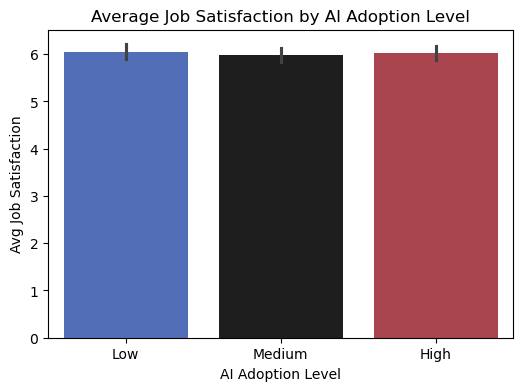

In [21]:
plt.figure(figsize=(6,4))

sns.barplot(x="AI_Adoption_Level", y="Job_Satisfaction", data=df, order=order,palette='icefire')

plt.title("Average Job Satisfaction by AI Adoption Level")
plt.xlabel("AI Adoption Level")
plt.ylabel("Avg Job Satisfaction")

plt.show()

* Job satisfaction remains almost the same across all levels of AI adoption.
* Increasing AI usage:
  
❌ Does NOT reduce satisfaction

❌ Does NOT significantly increase satisfaction

So AI has neutral impact on employee satisfaction

#### Most Imp:
* "AI improves productivity without negatively affecting employee satisfaction.”

#### Q10:What is the distribution of:

* Work_Hours_Per_Week
* Remote_Work (Yes/No)

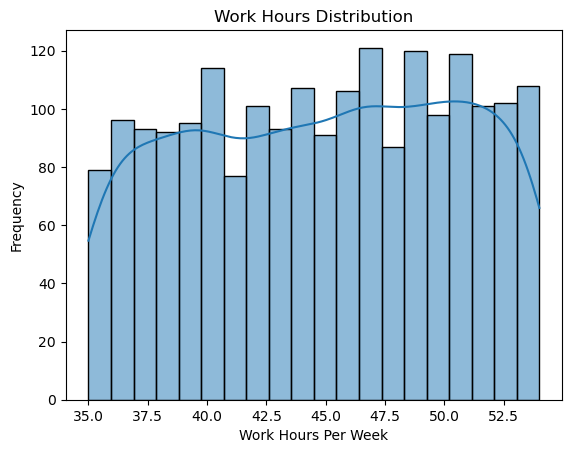

In [22]:
#Work Hours
sns.histplot(df["Work_Hours_Per_Week"], bins=20, kde=True)

plt.title("Work Hours Distribution")
plt.xlabel("Work Hours Per Week")
plt.ylabel("Frequency")

plt.show()

As we can see most of the weekly working hours of mostly employes are between 45.0 hours to 50 hours but some exceed this limit and 
work extra hard.

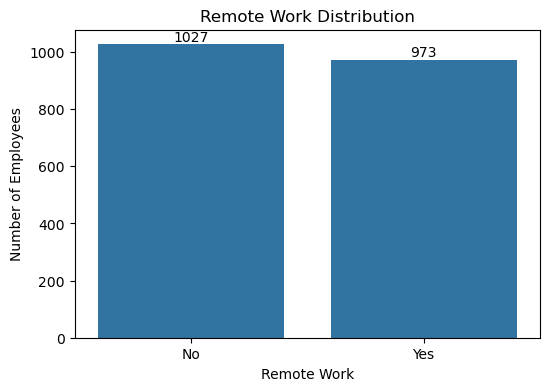

In [23]:
#Remote work or office
plt.figure(figsize=(6,4))

ax = sns.countplot(x="Remote_Work", data=df)

# Add labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Remote Work Distribution")
plt.xlabel("Remote Work")
plt.ylabel("Number of Employees")

plt.show()

#### Conclusion:
“Work hours are balanced, and employees are almost evenly split between remote and office work, indicating a hybrid work environment